⚠️ This notebook is for experimentation and analysis only.
Production logic is implemented under `src/` and `pipeline/`.


In [22]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [23]:
use_cols = [
    "item_id","cat_id", "store_id", "date", "sales",
    "weekday", "event_name_1"
]

chunks = pd.read_csv(
    "../data/interim/sales_long.csv",
    usecols=use_cols,
    parse_dates=["date"],
    chunksize=1_000_000,          
)


In [24]:
eda_df = []

for chunk in chunks:
    for store_id, store_df in chunk.groupby("store_id"):
        sample = store_df.sample(
            n=min(10_000, len(store_df)),
            random_state=42
        )
        eda_df.append(sample)

eda_df = pd.concat(eda_df, ignore_index=True)



In [25]:
eda_df.shape

(5900000, 7)

In [26]:
eda_df.head()

,item_id,cat_id,store_id,sales,date,weekday,event_name_1
0,FOODS_3_417,FOODS,CA_1,0,2011-02-25,Friday,NaN
1,FOODS_1_070,FOODS,CA_1,0,2011-02-04,Friday,NaN
2,HOUSEHOLD_2_289,HOUSEHOLD,CA_1,0,2011-01-29,Saturday,NaN
3,FOODS_2_362,FOODS,CA_1,0,2011-02-09,Wednesday,NaN
4,FOODS_3_231,FOODS,CA_1,1,2011-02-25,Friday,NaN


In [27]:
eda_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5900000 entries, 0 to 5899999
Data columns (total 7 columns):
 #   Column        Dtype         
---  ------        -----         
 0   item_id       object        
 1   cat_id        object        
 2   store_id      object        
 3   sales         int64         
 4   date          datetime64[ns]
 5   weekday       object        
 6   event_name_1  object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 315.1+ MB


In [28]:
eda_df["sales"].describe()


count    5.900000e+06
mean     1.135820e+00
std      3.815889e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      5.610000e+02
Name: sales, dtype: float64

Retail demand is sparse and intermittent, which makes forecasting non-trivial

In [29]:
zero_sales_ratio = (eda_df["sales"] == 0).mean()
zero_sales_ratio


np.float64(0.6801445762711864)

A large proportion of zero-sales days indicates intermittent demand patterns

In [30]:
daily_sales = (eda_df.groupby("date")["sales"].sum())


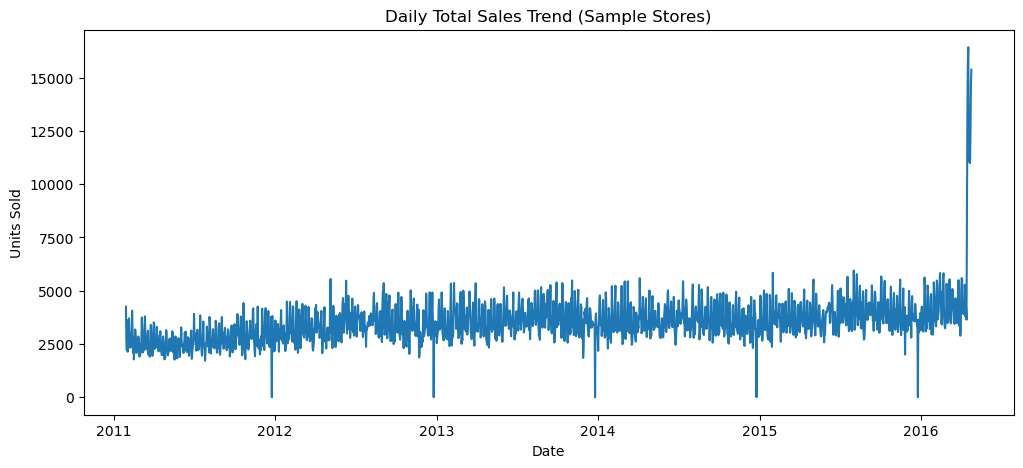

In [31]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Daily Total Sales Trend (Sample Stores)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

Sales exhibit strong temporal patterns with visible seasonal fluctuations.

In [32]:
weekday_sales = (eda_df.groupby("weekday")["sales"].mean().reindex(
        ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    ))


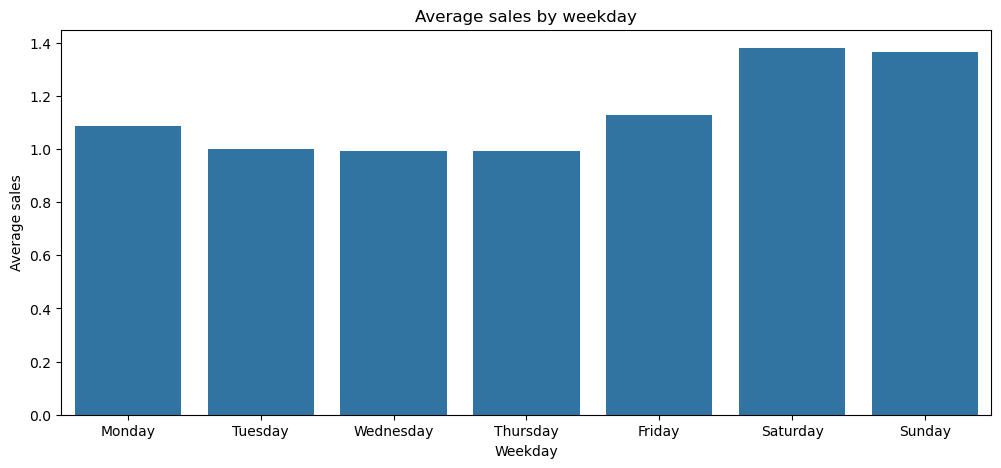

In [33]:
plt.figure(figsize=(12,5))
sns.barplot(weekday_sales)
plt.title("Average sales by weekday")
plt.xlabel("Weekday")
plt.ylabel("Average sales")
plt.show()


In [34]:
dict_event = {True : "Event", False: "Non-Event"}

eda_df["is_event"] = eda_df["event_name_1"].notna().map(dict_event)

event_sales = eda_df.groupby("is_event")["sales"].mean()
event_sales


is_event
Event        1.077317
Non-Event    1.140881
Name: sales, dtype: float64

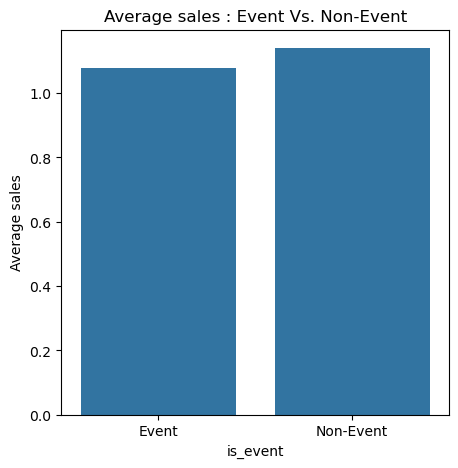

In [35]:
plt.figure(figsize=(5,5))
sns.barplot(event_sales)
plt.title("Average sales : Event Vs. Non-Event")
plt.ylabel("Average sales")
plt.show()

In [36]:
eda_df.groupby(
    ["cat_id", "is_event"]
)["sales"].mean().unstack()


is_event,Event,Non-Event
cat_id,,
FOODS,1.592386,1.656882
HOBBIES,0.531055,0.585970
HOUSEHOLD,0.657577,0.722377


In [37]:
store_sales = (eda_df.groupby("store_id")["sales"].mean())


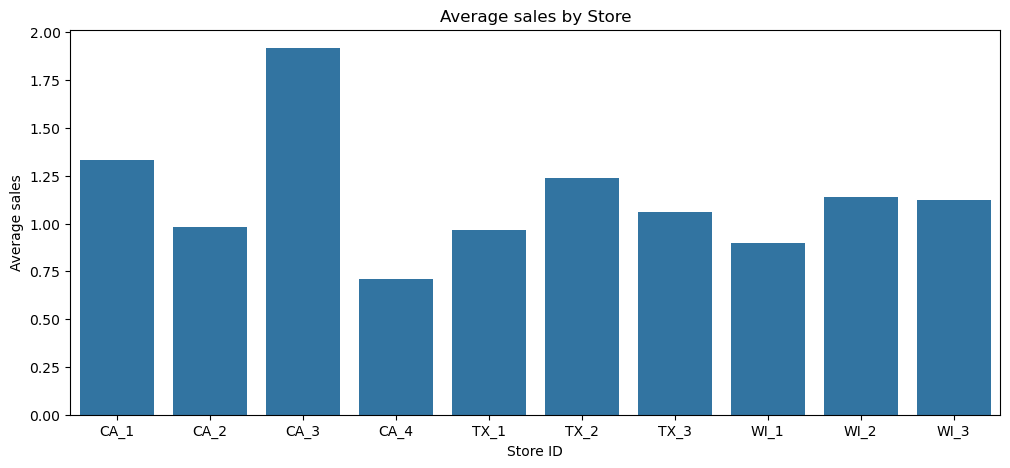

In [38]:
plt.figure(figsize=(12,5))
sns.barplot(store_sales)
plt.title("Average sales by Store")
plt.xlabel("Store ID")
plt.ylabel("Average sales")
plt.show()

# Exploratory Data Analysis (EDA) – Insights

This EDA was conducted on a sampled subset of the **M5 sales dataset** using a
chunk-based loading strategy due to the large scale of the data.
The objective is to understand **demand sparsity, temporal behavior,
seasonality, event effects, and store-level variations**.

---

## Sales Distribution & Demand Sparsity

Summary statistics of daily item–store sales:

- **Mean sales:** ~**1.14 units**
- **Standard deviation:** ~**3.82 units**
- **Minimum sales:** **0 units**
- **Median (50%) sales:** **0 units**
- **75th percentile:** **1 unit**
- **Maximum observed sales:** **561 units**

The median value of zero indicates that **most item–store combinations do not sell on a given day**.

### Zero-Sales Ratio

- **~68% of observations have zero sales**

This confirms that the dataset exhibits **highly sparse and intermittent demand**, which is typical in large-scale retail datasets.

**Implication:**  
Forecasting models must explicitly handle zero-inflated demand and should rely on
historical patterns rather than assuming continuous sales.

---

## Temporal Sales Patterns

### Daily Total Sales Trend

The aggregated daily sales trend (across sampled stores) shows:

- A **clear long-term upward trend**
- Strong **seasonal fluctuations**
- Sharp spikes toward the end of the timeline, corresponding to **major holiday periods**
- Occasional drops, likely due to calendar or demand shocks

The series is **non-stationary**, reinforcing the need for lag-based and rolling
features rather than classical stationary assumptions.

---

## Weekly Seasonality

Average sales by weekday show a strong weekly pattern:

- Sales are **lowest between Tuesday and Thursday**
- Demand starts increasing on **Friday**
- **Saturday and Sunday have the highest average sales**

This reflects typical consumer shopping behavior, with higher demand during weekends.

**Implication:**  
Day-of-week effects are significant and should be explicitly modeled.

---

## Event vs Non-Event Sales Behavior

Average sales comparison between event and non-event days shows:

- **Non-event days have slightly higher average sales than event days**

This indicates that **calendar events do not uniformly increase demand** across all items.

**Key Insight:**  
Events act as demand redistributors rather than universal demand boosters.

---

## Store-Level Demand Differences

Average sales by store reveal clear heterogeneity:

- **CA_3 exhibits the highest average sales**
- **CA_4 has the lowest average sales**
- California stores generally outperform Texas and Wisconsin stores
- Significant variation exists even within the same state

**Implication:**  
Store-level characteristics strongly influence demand and must be incorporated into
the forecasting model.

---

## Key EDA Insights

- Retail demand is **highly sparse**, with ~68% zero-sales observations
- Strong **weekly seasonality** is present, with weekend peaks
- Sales patterns are **non-stationary** over time
- Event effects are **not globally positive**
- Demand varies significantly across stores

---

## Modeling Implications

Based on the EDA findings:

- Lag features (7, 14, 28 days) are essential
- Rolling averages help smooth intermittent demand
- Weekday features must be included
- Event indicators should be modeled flexibly
- Store-level identifiers are critical
- Tree-based models (e.g., **LightGBM, XGBoost**) are well suited for this data

---

## Conclusion

The EDA confirms that the M5 dataset represents a **realistic and challenging
retail forecasting problem**, characterized by sparse demand, strong seasonality,
and heterogeneous store behavior. These characteristics justify the use of
feature-rich, non-linear machine learning models for accurate demand forecasting.
